# 01. Initial EDA

Two parts:

1. Per-ticker daily price comparison plots (AlphaVantage vs yfinance), saved under `output/01_initial_eda/`:
    - `full_history/` - full overlap period
    - `from_2020/` - restricted to 2020-01-01 onward
    - `difference_full_history/` - Alpha - yfinance diff, full history
    - `difference_from_2020/` - same diff from 2020 onward
2. Data availability heatmaps for `daily_alpha`, `daily_yf`, `options_alpha` over 2020-01-01 -> `settings.UNIVERSE_END_DATE`, sorted so the earliest-listed tickers sit at the top. Stock splits are overlaid as triangle markers (green up = forward split, red down = reverse split).

Tickers come from `config.FILTERED_TICKERS` (59).


In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from config import FILTERED_TICKERS, settings

## Part 1 - Daily price comparison plots

One plot per ticker per view (4 views). Saves PNGs to disk and prints totals.


In [2]:
DATA_DIR = Path.cwd() / "data"
ALPHA_DIR = DATA_DIR / "daily_alpha"
YF_DIR = DATA_DIR / "daily_yf"
OUTPUT_BASE_DIR = Path.cwd() / "output" / "01_initial_eda"
OUTPUT_FULL_DIR = OUTPUT_BASE_DIR / "full_history"
OUTPUT_2020_DIR = OUTPUT_BASE_DIR / "from_2020"
OUTPUT_DIFF_FULL_DIR = OUTPUT_BASE_DIR / "difference_full_history"
OUTPUT_DIFF_2020_DIR = OUTPUT_BASE_DIR / "difference_from_2020"

END_DATE = pd.Timestamp(settings.UNIVERSE_END_DATE)

for d in (OUTPUT_FULL_DIR, OUTPUT_2020_DIR, OUTPUT_DIFF_FULL_DIR, OUTPUT_DIFF_2020_DIR):
    d.mkdir(parents=True, exist_ok=True)

saved_full = saved_2020 = saved_diff_full = saved_diff_2020 = 0
skipped = []
skipped_2020 = []


def save_comparison_plot(df, ticker, out_path, title_suffix):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(
        df["date"], df["adjusted_close_alpha"], label="Alpha Vantage", linewidth=1.4
    )
    ax.plot(
        df["date"], df["adjusted_close_yf"], label="yfinance", linewidth=1.2, alpha=0.9
    )
    ax.set_title(f"{ticker} Daily Adjusted Close ({title_suffix})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Adjusted Close")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)


def save_difference_plot(df_outer, ticker, out_path, title_suffix):
    if df_outer.empty:
        return False

    present = df_outer.dropna(
        subset=["adjusted_close_alpha", "adjusted_close_yf"]
    ).copy()
    missing_alpha = df_outer[
        df_outer["adjusted_close_alpha"].isna() & df_outer["adjusted_close_yf"].notna()
    ]
    missing_yf = df_outer[
        df_outer["adjusted_close_yf"].isna() & df_outer["adjusted_close_alpha"].notna()
    ]

    if present.empty and missing_alpha.empty and missing_yf.empty:
        return False

    fig, ax = plt.subplots(figsize=(12, 3.8))
    if not present.empty:
        present["diff"] = present["adjusted_close_alpha"] - present["adjusted_close_yf"]
        ax.plot(
            present["date"],
            present["diff"],
            color="tab:red",
            linewidth=1.2,
            label="Alpha - yfinance",
        )
        y_min = float(present["diff"].min())
        y_max = float(present["diff"].max())
    else:
        y_min, y_max = -1.0, 1.0

    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.8)
    y_span = max(y_max - y_min, 1e-6)
    alpha_marker_y = y_max + 0.08 * y_span
    yf_marker_y = y_min - 0.08 * y_span

    if not missing_alpha.empty:
        ax.scatter(
            missing_alpha["date"],
            [alpha_marker_y] * len(missing_alpha),
            marker="v",
            s=12,
            color="tab:blue",
            alpha=0.8,
            label="Date missing in Alpha",
        )
    if not missing_yf.empty:
        ax.scatter(
            missing_yf["date"],
            [yf_marker_y] * len(missing_yf),
            marker="^",
            s=12,
            color="tab:orange",
            alpha=0.8,
            label="Date missing in yfinance",
        )

    lower = min(y_min, yf_marker_y if not missing_yf.empty else y_min)
    upper = max(y_max, alpha_marker_y if not missing_alpha.empty else y_max)
    pad = 0.06 * max(upper - lower, 1e-6)
    ax.set_ylim(lower - pad, upper + pad)

    ax.set_title(
        f"{ticker} Adjusted Close Difference ({title_suffix}) | "
        f"Missing Alpha: {len(missing_alpha)}, Missing yfinance: {len(missing_yf)}"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Difference (USD)")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    return True


for ticker in FILTERED_TICKERS:
    alpha_path = ALPHA_DIR / f"{ticker}.csv"
    yf_path = YF_DIR / f"{ticker}.csv"

    if not alpha_path.exists() or not yf_path.exists():
        skipped.append((ticker, "missing one source file"))
        continue

    alpha_df = pd.read_csv(alpha_path, usecols=["date", "adjusted_close"]).rename(
        columns={"adjusted_close": "adjusted_close_alpha"}
    )
    yf_df = pd.read_csv(yf_path, usecols=["date", "adjusted_close"]).rename(
        columns={"adjusted_close": "adjusted_close_yf"}
    )

    alpha_df["date"] = pd.to_datetime(alpha_df["date"], errors="coerce")
    yf_df["date"] = pd.to_datetime(yf_df["date"], errors="coerce")
    alpha_df = alpha_df.dropna(subset=["date", "adjusted_close_alpha"])
    yf_df = yf_df.dropna(subset=["date", "adjusted_close_yf"])

    merged_outer = alpha_df.merge(yf_df, on="date", how="outer").sort_values("date")
    merged_outer = merged_outer[merged_outer["date"] <= END_DATE]
    merged = merged_outer.dropna(subset=["adjusted_close_alpha", "adjusted_close_yf"])

    if merged.empty:
        skipped.append((ticker, "no overlapping dates"))
        continue

    save_comparison_plot(
        merged,
        ticker,
        OUTPUT_FULL_DIR / f"{ticker}_daily_price_comparison_full.png",
        "Full History",
    )
    saved_full += 1
    if save_difference_plot(
        merged_outer,
        ticker,
        OUTPUT_DIFF_FULL_DIR / f"{ticker}_daily_price_difference_full.png",
        "Full History",
    ):
        saved_diff_full += 1

    merged_2020_outer = merged_outer[merged_outer["date"] >= pd.Timestamp("2020-01-01")]
    merged_2020 = merged_2020_outer.dropna(
        subset=["adjusted_close_alpha", "adjusted_close_yf"]
    )
    if merged_2020.empty:
        skipped_2020.append((ticker, "no overlapping dates in 2020+"))
        continue

    save_comparison_plot(
        merged_2020,
        ticker,
        OUTPUT_2020_DIR / f"{ticker}_daily_price_comparison_2020_onward.png",
        "2020 Onward",
    )
    saved_2020 += 1
    if save_difference_plot(
        merged_2020_outer,
        ticker,
        OUTPUT_DIFF_2020_DIR / f"{ticker}_daily_price_difference_2020_onward.png",
        "2020 Onward",
    ):
        saved_diff_2020 += 1

print(f"Using END_DATE from config settings: {END_DATE.date()}")
print(f"Saved full-history plots: {saved_full} -> {OUTPUT_FULL_DIR}")
print(f"Saved 2020+ plots: {saved_2020} -> {OUTPUT_2020_DIR}")
print(
    f"Saved full-history difference plots: {saved_diff_full} -> {OUTPUT_DIFF_FULL_DIR}"
)
print(f"Saved 2020+ difference plots: {saved_diff_2020} -> {OUTPUT_DIFF_2020_DIR}")

if skipped:
    print(f"Skipped entirely: {len(skipped)}")
    print(skipped[:10])
if skipped_2020:
    print(f"Skipped 2020+ only: {len(skipped_2020)}")
    print(skipped_2020[:10])

Using END_DATE from config settings: 2026-04-02
Saved full-history plots: 59 -> D:\AT82.04-Option-Screener-with-Price-Prediction\experiments\output\01_initial_eda\full_history
Saved 2020+ plots: 59 -> D:\AT82.04-Option-Screener-with-Price-Prediction\experiments\output\01_initial_eda\from_2020
Saved full-history difference plots: 59 -> D:\AT82.04-Option-Screener-with-Price-Prediction\experiments\output\01_initial_eda\difference_full_history
Saved 2020+ difference plots: 59 -> D:\AT82.04-Option-Screener-with-Price-Prediction\experiments\output\01_initial_eda\difference_from_2020


## Part 2 - Data availability

Count how many trading-day rows (daily) or chain files (options) each ticker has per month across the 2020-01-01 -> 2026-04-02 window. Heatmap cells are normalized by the expected number of US business days in the month (so 1.0 means fully populated). Rows are sorted by first-data month so the earliest tickers sit at the top and newer IPOs cascade down. Stock splits are overlaid as triangle markers (green up = forward split, red down = reverse split).


In [3]:
WINDOW_START = pd.Timestamp("2020-01-01")
WINDOW_END = pd.Timestamp(settings.UNIVERSE_END_DATE)
MONTHS = pd.period_range(start=WINDOW_START, end=WINDOW_END, freq="M")

BDAYS = pd.bdate_range(WINDOW_START, WINDOW_END)
EXPECTED_PER_MONTH = (
    BDAYS.to_series().groupby(BDAYS.to_period("M")).size().reindex(MONTHS, fill_value=0)
)


def monthly_count_daily(dir_name: str) -> pd.DataFrame:
    rows = {}
    for t in FILTERED_TICKERS:
        p = Path("data") / dir_name / f"{t}.csv"
        if not p.exists():
            rows[t] = pd.Series(0, index=MONTHS)
            continue
        df = pd.read_csv(p, usecols=["date"])
        df["date"] = pd.to_datetime(df["date"])
        df = df[(df["date"] >= WINDOW_START) & (df["date"] <= WINDOW_END)]
        rows[t] = (
            df["date"].dt.to_period("M").value_counts().reindex(MONTHS, fill_value=0)
        )
    return pd.DataFrame(rows).T


_DATE_RE = re.compile(r"_(\d{4}-\d{2}-\d{2})\.csv$")


def monthly_count_options() -> pd.DataFrame:
    rows = {}
    for t in FILTERED_TICKERS:
        tdir = Path("data/options_alpha") / t
        if not tdir.is_dir():
            rows[t] = pd.Series(0, index=MONTHS)
            continue
        dates = [m.group(1) for f in tdir.iterdir() if (m := _DATE_RE.search(f.name))]
        if not dates:
            rows[t] = pd.Series(0, index=MONTHS)
            continue
        s = pd.to_datetime(pd.Series(dates))
        s = s[(s >= WINDOW_START) & (s <= WINDOW_END)]
        rows[t] = s.dt.to_period("M").value_counts().reindex(MONTHS, fill_value=0)
    return pd.DataFrame(rows).T


av_monthly = monthly_count_daily("daily_alpha")
yf_monthly = monthly_count_daily("daily_yf")
opt_monthly = monthly_count_options()


def first_last(counts):
    out = []
    for t in FILTERED_TICKERS:
        row = counts.loc[t]
        nz = row[row > 0]
        out.append(
            {
                "ticker": t,
                "n": int(row.sum()),
                "first": str(nz.index.min()) if len(nz) else "",
                "last": str(nz.index.max()) if len(nz) else "",
            }
        )
    return pd.DataFrame(out).set_index("ticker")


av_fl = first_last(av_monthly)
yf_fl = first_last(yf_monthly)
opt_fl = first_last(opt_monthly)

summary = pd.DataFrame(
    {
        "av_days": av_fl["n"],
        "yf_days": yf_fl["n"],
        "opt_days": opt_fl["n"],
        "av_first": av_fl["first"],
        "opt_first": opt_fl["first"],
    }
)
print(
    f"tickers: {len(summary)}  |  expected trading days in window: {EXPECTED_PER_MONTH.sum()}"
)
summary

tickers: 59  |  expected trading days in window: 1632


,av_days,yf_days,opt_days,av_first,opt_first
ticker,,,,,
AAPL,1571,1571,1570,2020-01,2020-01
ALKT,1249,1249,1102,2021-04,2021-11
AMAT,1571,1571,1570,2020-01,2020-01
AMD,1571,1571,1570,2020-01,2020-01
AMZN,1571,1571,1570,2020-01,2020-01
APLD,1480,996,716,2020-01,2023-05
ARQQ,1148,1257,1056,2021-09,2021-10
AVGO,1571,1571,1570,2020-01,2020-01
BBAI,1076,1256,1083,2021-12,2021-12


### Stock splits in the window

Splits are extracted from `daily_alpha/<ticker>.csv` where `split_coefficient != 1.0`. Coefficients > 1 are forward splits (e.g. AAPL 4-for-1 = coef 4.0); coefficients < 1 are reverse splits.


In [4]:
splits_df = []
for t in FILTERED_TICKERS:
    p = Path("data/daily_alpha") / f"{t}.csv"
    if not p.exists():
        continue
    df = pd.read_csv(p, usecols=["date", "split_coefficient"])
    df["date"] = pd.to_datetime(df["date"])
    df = df[(df["date"] >= WINDOW_START) & (df["date"] <= WINDOW_END)]
    for _, row in df[df["split_coefficient"] != 1.0].iterrows():
        splits_df.append(
            {
                "ticker": t,
                "date": row["date"].strftime("%Y-%m-%d"),
                "coef": row["split_coefficient"],
            }
        )

splits_df = pd.DataFrame(splits_df)
print(
    f"splits in window: {len(splits_df)} across {splits_df['ticker'].nunique()} tickers"
)
splits_df

splits in window: 18 across 16 tickers


,ticker,date,coef
0,AAPL,2020-08-31,4.000000
1,AMZN,2022-06-06,20.000000
2,APLD,2022-04-13,0.166667
3,ARQQ,2024-09-25,0.040000
4,AVGO,2024-07-15,10.000000
5,BYRN,2021-04-27,0.100000
6,DELL,2021-11-02,1.973000
7,GME,2022-07-22,4.000000
8,GOOGL,2022-07-18,20.000000
9,KULR,2025-06-23,0.125000


### Heatmap plotting helpers

Sort by first-data month (ascending, ticker alpha as tiebreaker) and overlay split markers at each `(ticker_row, month_column)` cell.


In [5]:
AVAIL_DIR = Path.cwd() / "output" / "01_initial_eda" / "availability"
AVAIL_DIR.mkdir(parents=True, exist_ok=True)


def sort_by_first_data(matrix):
    first_month = {}
    for t in matrix.index:
        nz = matrix.loc[t][matrix.loc[t] > 0]
        first_month[t] = nz.index.min() if len(nz) else pd.Period("9999-12", freq="M")
    order = sorted(matrix.index, key=lambda t: (first_month[t], t))
    return matrix.loc[order]


def plot_heatmap(matrix, title, png_path, denom, splits):
    matrix = sort_by_first_data(matrix)
    normed = matrix.div(denom, axis=1).clip(upper=1.0).fillna(0.0)

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(
        normed.values,
        aspect="auto",
        cmap="plasma",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index, fontsize=7)
    month_labels = [str(p) for p in matrix.columns]
    tick_step = 3
    ax.set_xticks(range(0, len(month_labels), tick_step))
    ax.set_xticklabels(month_labels[::tick_step], rotation=60, ha="right", fontsize=8)

    row_lookup = {t: i for i, t in enumerate(matrix.index)}
    col_lookup = {p: i for i, p in enumerate(matrix.columns)}
    fwd_x, fwd_y, rev_x, rev_y = [], [], [], []
    for _, row in splits.iterrows():
        r = row_lookup.get(row["ticker"])
        c = col_lookup.get(pd.Period(row["date"], freq="M"))
        if r is None or c is None:
            continue
        if row["coef"] > 1:
            fwd_x.append(c)
            fwd_y.append(r)
        else:
            rev_x.append(c)
            rev_y.append(r)
    if fwd_x:
        ax.scatter(
            fwd_x,
            fwd_y,
            marker="^",
            s=70,
            facecolors="white",
            edgecolors="#0a7d3a",
            linewidths=1.4,
            label="Forward split",
            zorder=3,
        )
    if rev_x:
        ax.scatter(
            rev_x,
            rev_y,
            marker="v",
            s=70,
            facecolors="white",
            edgecolors="#b4272b",
            linewidths=1.4,
            label="Reverse split",
            zorder=3,
        )

    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Ticker")
    cbar = fig.colorbar(im, ax=ax, shrink=0.7)
    cbar.set_label("Fraction of expected trading days")
    if fwd_x or rev_x:
        ax.legend(loc="lower right", framealpha=0.85)

    fig.tight_layout()
    fig.savefig(png_path, dpi=120)
    plt.show()
    plt.close(fig)

### daily_alpha availability


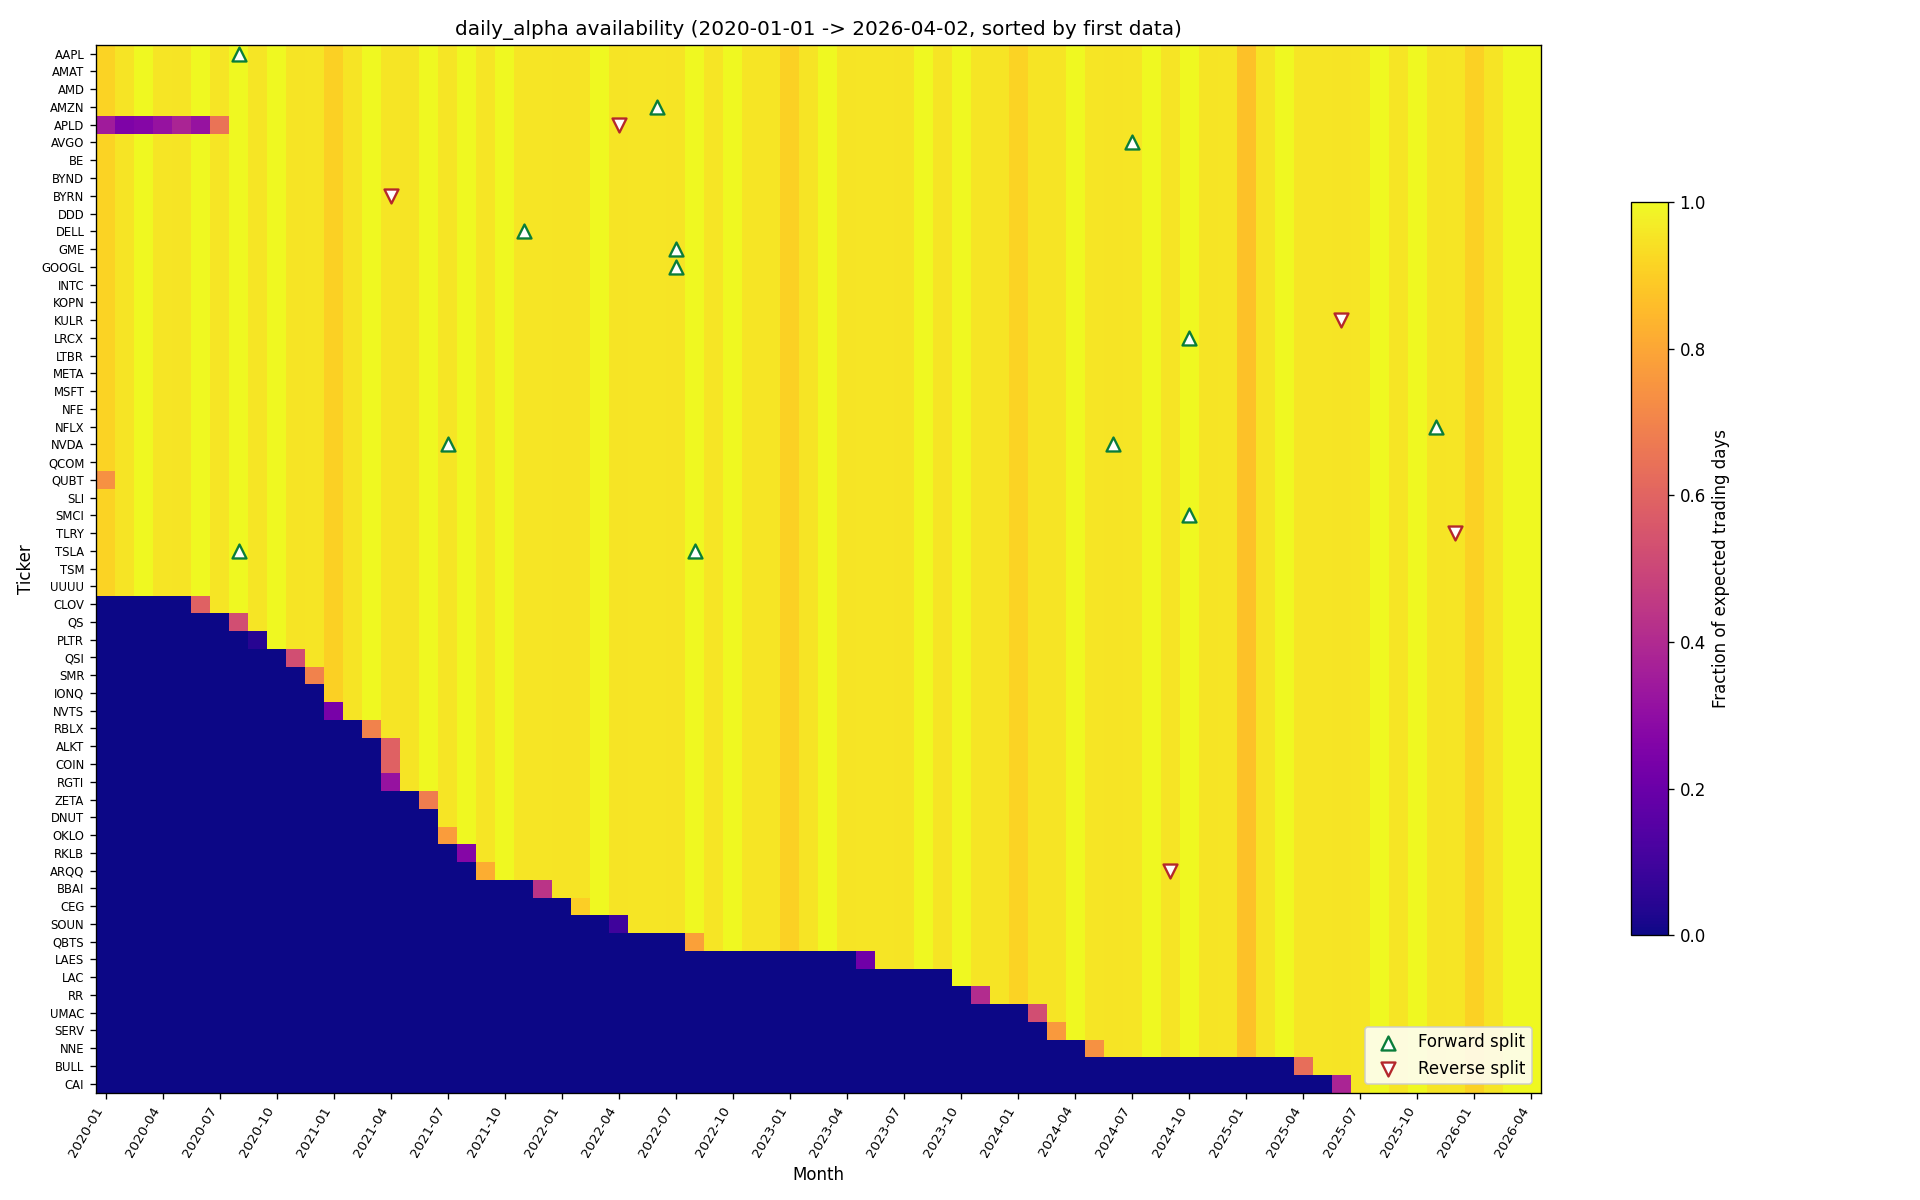

In [6]:
plot_heatmap(
    av_monthly,
    f"daily_alpha availability ({WINDOW_START.date()} -> {WINDOW_END.date()}, sorted by first data)",
    AVAIL_DIR / "daily_alpha_heatmap.png",
    EXPECTED_PER_MONTH,
    splits_df,
)

### daily_yf availability


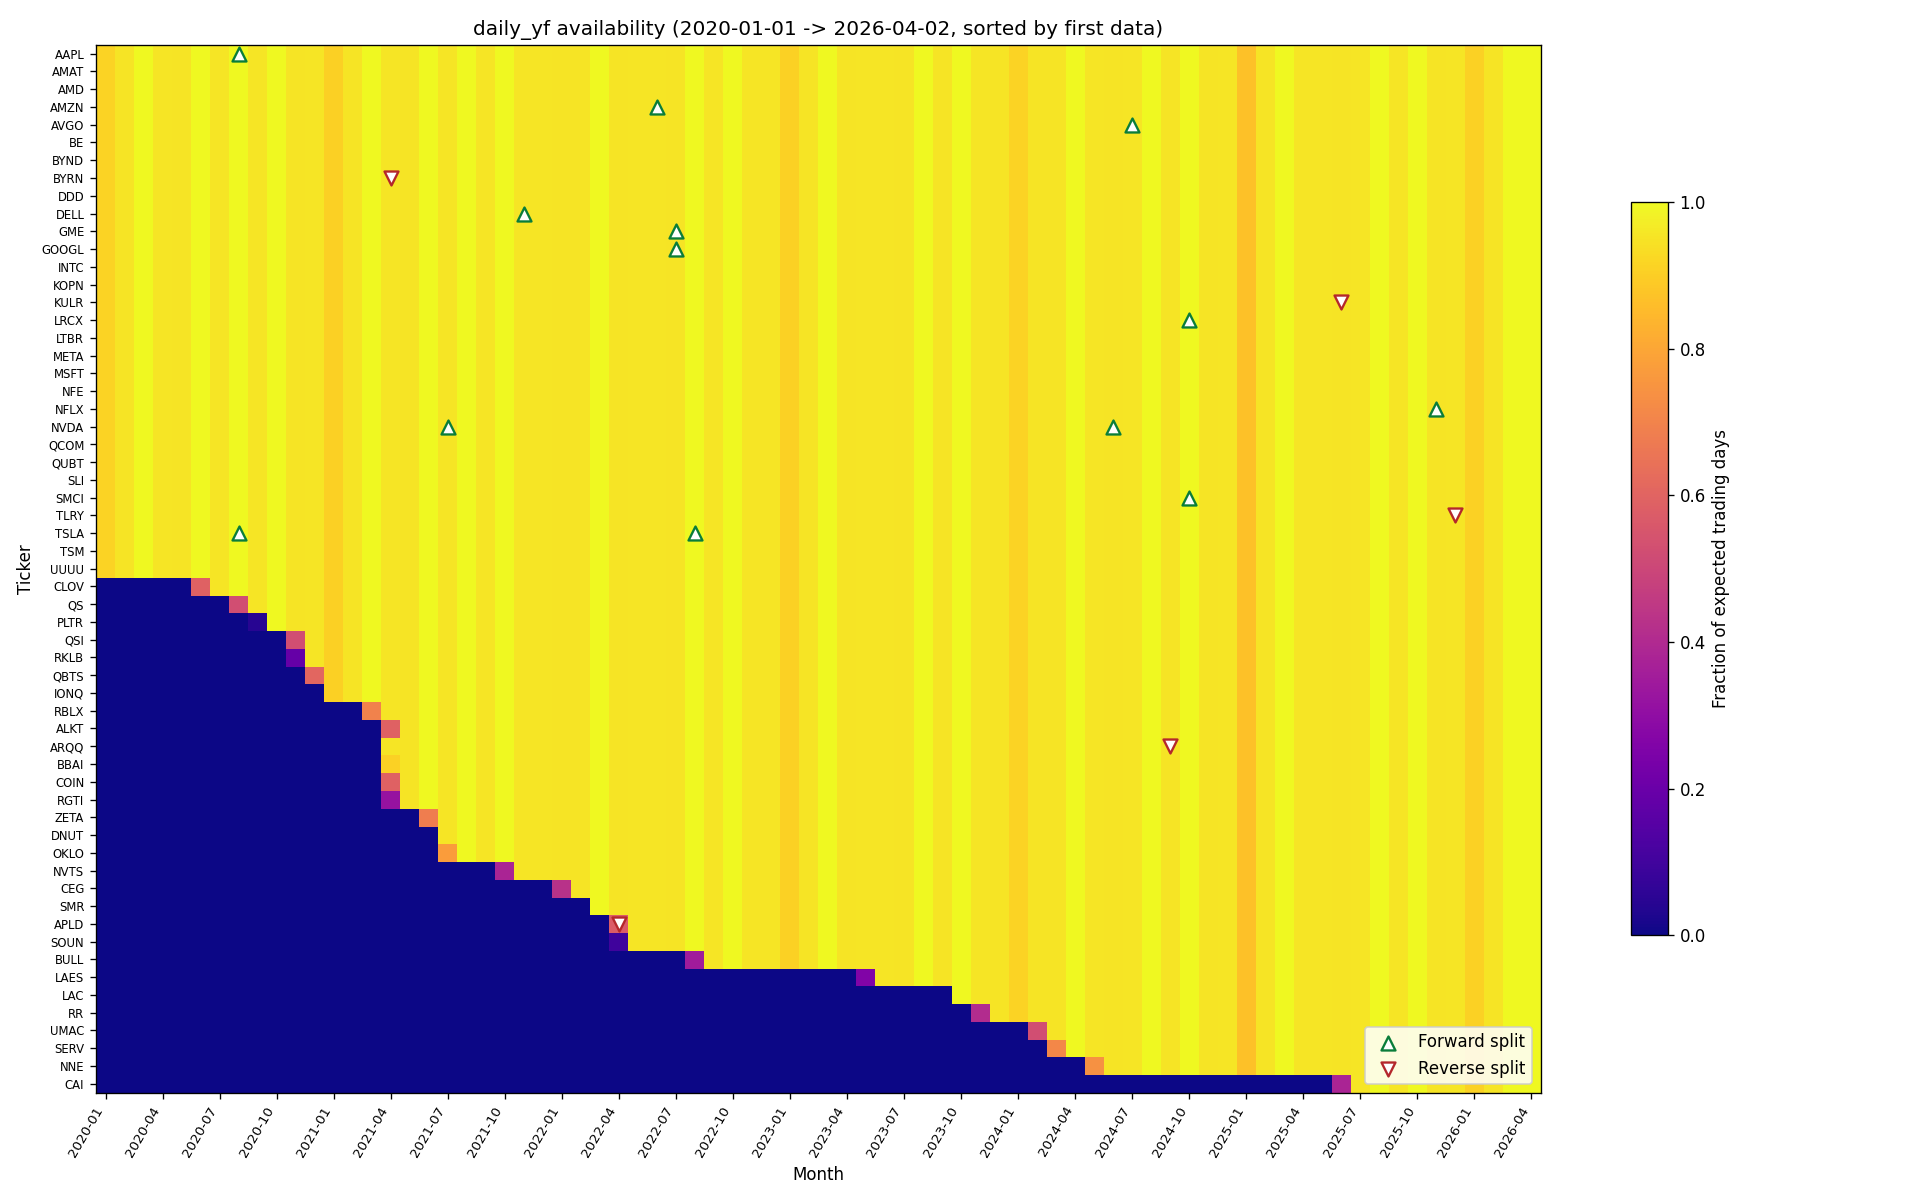

In [7]:
plot_heatmap(
    yf_monthly,
    f"daily_yf availability ({WINDOW_START.date()} -> {WINDOW_END.date()}, sorted by first data)",
    AVAIL_DIR / "daily_yf_heatmap.png",
    EXPECTED_PER_MONTH,
    splits_df,
)

### options_alpha availability


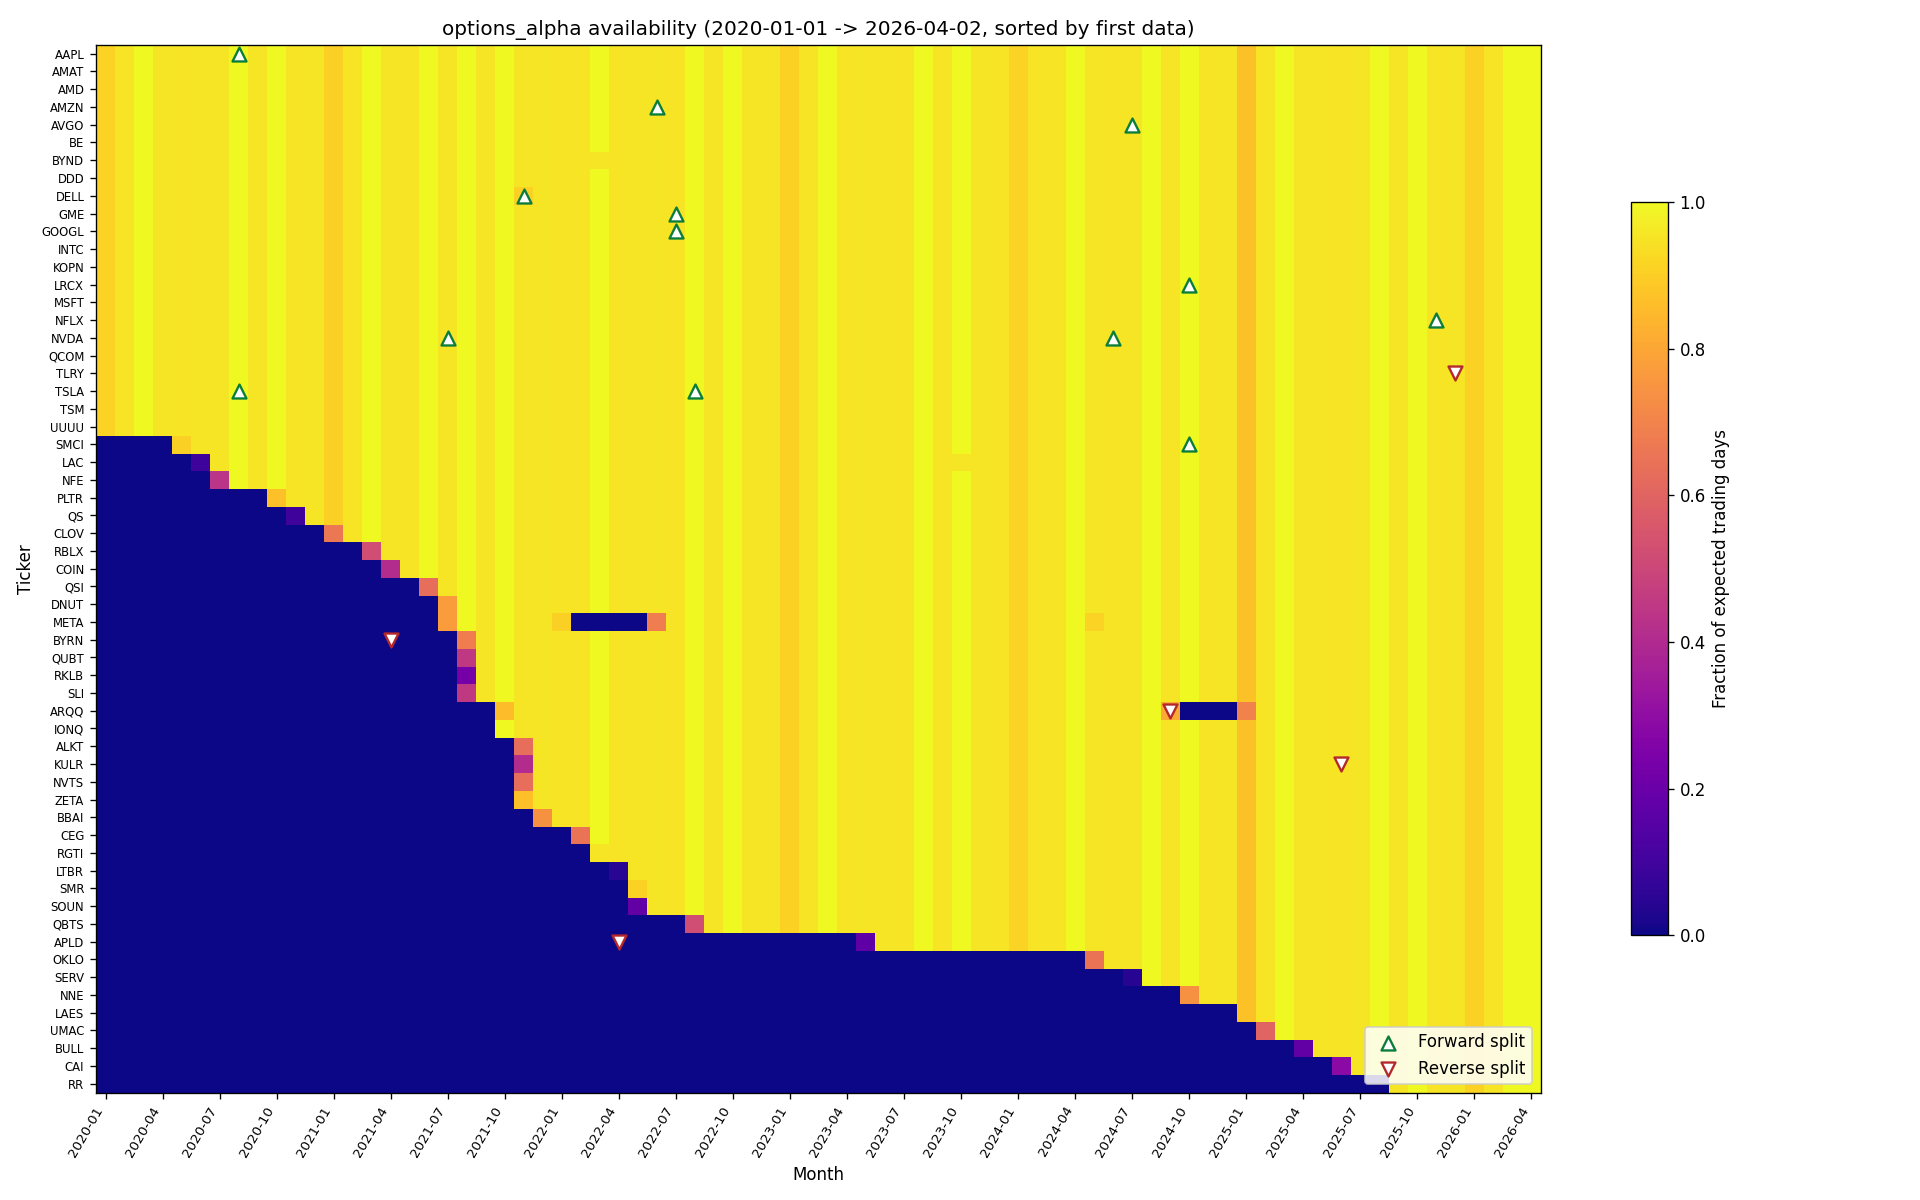

In [8]:
plot_heatmap(
    opt_monthly,
    f"options_alpha availability ({WINDOW_START.date()} -> {WINDOW_END.date()}, sorted by first data)",
    AVAIL_DIR / "options_alpha_heatmap.png",
    EXPECTED_PER_MONTH,
    splits_df,
)